In [1]:
# Cell 0: Import Dependencies and Load Simplified Dataset
# Notebook: 03_model_training_enhanced.ipynb
# Purpose: Train models on simplified dataset for Agentic AI prototype

import time
import json
import joblib
from tensorflow.keras import layers, models, callbacks
from tensorflow import keras
import tensorflow as tf
import xgboost as xgb
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization

# Machine Learning

# Deep Learning

# Utilities

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("NOTEBOOK: 03_MODEL_TRAINING_ENHANCED.IPynb")
print("Strategy: Train on simplified 1M dataset → Focus on Agentic AI")
print("=" * 80)

# ============================================================================
# PROJECT PATHS
# ============================================================================

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists()),
    Path.cwd(),
)
DATA_DIR = PROJECT_ROOT / 'data'
DATASETS_DIR = PROJECT_ROOT / 'datasets'
MODELS_DIR = PROJECT_ROOT / 'models'
PLOTS_DIR = PROJECT_ROOT / 'outputs' / 'plots'

# Create directories
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / 'processed').mkdir(parents=True, exist_ok=True)

print("\n📁 Project Paths:")
print(f"   Project Root: {PROJECT_ROOT}")
print(f"   Datasets:     {DATASETS_DIR}")
print(f"   Models:       {MODELS_DIR}")
print(f"   Plots:        {PLOTS_DIR}")

# ============================================================================
# LOAD SIMPLIFIED DATASET
# ============================================================================

print(f"\n{'='*80}")
print("LOADING SIMPLIFIED DATASET: ids-intrusion.csv")
print("="*80)

dataset_path = DATASETS_DIR / 'ids-intrusion.csv'

print(f"\n📊 Loading: {dataset_path}")
print(f"   File exists: {dataset_path.exists()}")

if not dataset_path.exists():
    print("\n❌ ERROR: Dataset not found!")
    print(f"   Expected path: {dataset_path}")
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")

# Load with progress
print("\n⏳ Reading CSV...")
start_time = time.time()

df = pd.read_csv(dataset_path)

load_time = time.time() - start_time

print(f"\n✅ Dataset loaded in {load_time:.2f} seconds!")

# ============================================================================
# DATASET OVERVIEW
# ============================================================================

print(f"\n{'='*80}")
print("DATASET OVERVIEW")
print("="*80)

print("\n📏 Shape:")
print(f"   Rows:    {df.shape[0]:>12,}")
print(f"   Columns: {df.shape[1]:>12}")

# Memory usage
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"   Memory:  {memory_mb:>12.2f} MB")

# Data types
print("\n🔢 Data Types:")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {str(dtype):10s}: {count:>3} columns")

# Columns
print(f"\n📋 Columns ({len(df.columns)}):")
feature_cols = [col for col in df.columns if col != 'Label']
print(f"   Features: {len(feature_cols)}")
print("   Label:    1 ('Label')")

# First few rows
print("\n👀 Sample Data (first 3 rows):")
print(df.head(3))

# ============================================================================
# LABEL ANALYSIS
# ============================================================================

print(f"\n{'='*80}")
print("LABEL DISTRIBUTION")
print("="*80)

if 'Label' not in df.columns:
    print("\n❌ ERROR: 'Label' column not found!")
    print(f"   Available columns: {df.columns.tolist()}")
    raise ValueError("Label column missing")

label_counts = df['Label'].value_counts()
print(f"\n🏷️  Attack Types: {df['Label'].nunique()}")
print(f"\n{'Class':<20} {'Count':>12} {'Percentage':>12}")
print("-" * 50)

for label, count in label_counts.items():
    pct = (count / len(df)) * 100
    print(f"{label:<20} {count:>12,} {pct:>11.2f}%")

# Imbalance ratio
majority = label_counts.max()
minority = label_counts.min()
imbalance_ratio = majority / minority

print("\n📊 Class Imbalance:")
print(f"   Majority class: {label_counts.idxmax()} ({majority:,})")
print(f"   Minority class: {label_counts.idxmin()} ({minority:,})")
print(f"   Imbalance ratio: {imbalance_ratio:.1f}:1")

if imbalance_ratio > 10:
    print("   Status: MODERATE imbalance (will use class weights)")
elif imbalance_ratio > 100:
    print("   Status: SEVERE imbalance (will use class weights)")
else:
    print("   Status: BALANCED dataset")

# ============================================================================
# DATA QUALITY CHECK
# ============================================================================

print(f"\n{'='*80}")
print("DATA QUALITY CHECK")
print("="*80)

# Missing values
missing_total = df.isnull().sum().sum()
missing_pct = (missing_total / (df.shape[0] * df.shape[1])) * 100
print(f"\n🔍 Missing values: {missing_total:,} ({missing_pct:.4f}%)")

if missing_total > 0:
    cols_with_missing = df.isnull().sum()[df.isnull().sum() > 0]
    print("   Columns with missing values:")
    for col, count in cols_with_missing.items():
        pct = (count / len(df)) * 100
        print(f"      {col}: {count:,} ({pct:.2f}%)")

# Duplicates
duplicates = df.duplicated().sum()
dup_pct = (duplicates / len(df)) * 100
print(f"\n🔍 Duplicate rows: {duplicates:,} ({dup_pct:.2f}%)")

# Infinite values
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[numeric_cols]).sum().sum()
print(f"\n🔍 Infinite values: {inf_count:,}")

# Non-numeric columns (should be minimal)
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
if 'Label' in non_numeric:
    non_numeric.remove('Label')
print(f"\n🔍 Non-numeric feature columns: {len(non_numeric)}")
if non_numeric:
    print(f"   {non_numeric}")

# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print("SUMMARY")
print("="*80)

print("\n✅ Dataset Ready:")
print(f"   Total samples:    {len(df):,}")
print(f"   Features:         {len(feature_cols)}")
print(f"   Attack classes:   {df['Label'].nunique()}")
print(f"   Memory usage:     {memory_mb:.2f} MB")

data_quality = "GOOD" if (missing_pct < 1 and dup_pct <
                          25 and inf_count < 10000) else "NEEDS CLEANING"
print(f"   Data quality:     {data_quality}")

print("\n🎯 Next Steps:")
print("   Cell 1: Data cleaning (handle missing/duplicates/infinites)")
print("   Cell 2: Preprocessing (split, scale)")
print("   Cell 3: Train Random Forest")
print("   Cell 4: Train XGBoost")
print("   Cell 5: Train DNN")
print("   Cell 6: Ensemble & evaluation")

print("\n💡 Research Strategy:")
print("   - Train on 3 real attacks (SSH, FTP bruteforce, Benign)")
print("   - Establish baseline ML performance")
print("   - Focus on Agentic AI autonomous behavior")
print("   - Demo simulated APT for complex scenario showcase")

print("\n✅ Ready to proceed!")

NOTEBOOK: 03_MODEL_TRAINING_ENHANCED.IPynb
Strategy: Train on simplified 1M dataset → Focus on Agentic AI

📁 Project Paths:
   Project Root: .
   Datasets:     ./datasets
   Models:       ./models
   Plots:        ./outputs/plots

LOADING SIMPLIFIED DATASET: ids-intrusion.csv

📊 Loading: ./datasets/ids-intrusion.csv
   File exists: True

⏳ Reading CSV...

✅ Dataset loaded in 1.80 seconds!

DATASET OVERVIEW

📏 Shape:
   Rows:       1,048,575
   Columns:           80
   Memory:        765.91 MB

🔢 Data Types:
   int64     :  54 columns
   float64   :  24 columns
   object    :   2 columns

📋 Columns (80):
   Features: 79
   Label:    1 ('Label')

👀 Sample Data (first 3 rows):
   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0         0         0  14/02/2018 08:31:01      112641719             3   
1         0         0  14/02/2018 08:33:50      112641466             3   
2         0         0  14/02/2018 08:36:39      112638623             3   

   Tot Bwd Pkts 

In [2]:
# Cell 1: Data Cleaning
# Purpose: Remove duplicates, handle missing/infinite values, drop non-feature columns

print("=" * 80)
print("CELL 1: DATA CLEANING")
print("=" * 80)

print("\n📊 Starting data:")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {df.shape[1]}")

# ============================================================================
# PART 1: REMOVE DUPLICATES
# ============================================================================

print(f"\n{'='*80}")
print("PART 1: REMOVE DUPLICATES")
print("="*80)

duplicates_before = df.duplicated().sum()
print(
    f"\n🔍 Duplicate rows: {duplicates_before:,} ({duplicates_before/len(df)*100:.2f}%)")

if duplicates_before > 0:
    print("⏳ Removing duplicates...")
    df_clean = df.drop_duplicates()
    removed = len(df) - len(df_clean)
    print(f"✅ Removed {removed:,} duplicate rows")
    print(f"   Remaining: {len(df_clean):,} rows")
else:
    df_clean = df.copy()
    print("✅ No duplicates found")

# ============================================================================
# PART 2: DROP NON-FEATURE COLUMNS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 2: DROP NON-FEATURE COLUMNS")
print("="*80)

# Drop Timestamp (not useful for ML)
cols_to_drop = ['Timestamp']

print(f"\n🗑️  Dropping columns: {cols_to_drop}")

for col in cols_to_drop:
    if col in df_clean.columns:
        df_clean = df_clean.drop(columns=[col])
        print(f"   ✅ Dropped: {col}")

print(f"\n📊 Remaining columns: {df_clean.shape[1]}")

# ============================================================================
# PART 3: HANDLE MISSING VALUES
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 3: HANDLE MISSING VALUES")
print("="*80)

missing_before = df_clean.isnull().sum().sum()
print(f"\n🔍 Missing values: {missing_before:,}")

if missing_before > 0:
    cols_with_missing = df_clean.isnull().sum()[df_clean.isnull().sum() > 0]
    print("\n   Columns with missing values:")
    for col, count in cols_with_missing.items():
        pct = (count / len(df_clean)) * 100
        print(f"      {col}: {count:,} ({pct:.2f}%)")

    # Strategy: Drop rows with missing values (only 0.22%)
    print("\n⏳ Dropping rows with missing values...")
    df_clean = df_clean.dropna()
    removed = missing_before
    print(f"✅ Removed {len(df) - len(df_clean):,} rows with missing values")
    print(f"   Remaining: {len(df_clean):,} rows")
else:
    print("✅ No missing values")

# ============================================================================
# PART 4: HANDLE INFINITE VALUES
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 4: HANDLE INFINITE VALUES")
print("="*80)

# Select only numeric columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
inf_count_before = np.isinf(df_clean[numeric_cols]).sum().sum()

print(f"\n🔍 Infinite values: {inf_count_before:,}")

if inf_count_before > 0:
    # Show which columns have infinites
    inf_cols = []
    for col in numeric_cols:
        inf_in_col = np.isinf(df_clean[col]).sum()
        if inf_in_col > 0:
            inf_cols.append((col, inf_in_col))

    print("\n   Columns with infinite values:")
    for col, count in sorted(inf_cols, key=lambda x: x[1], reverse=True)[:10]:
        print(f"      {col}: {count:,}")

    # Strategy: Replace inf with NaN, then drop those rows
    print("\n⏳ Replacing infinites with NaN and dropping...")
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    df_clean = df_clean.dropna()

    removed_inf = inf_count_before
    print(
        f"✅ Removed {len(df) - len(df_clean):,} rows total (including inf values)")
    print(f"   Remaining: {len(df_clean):,} rows")
else:
    print("✅ No infinite values")

# ============================================================================
# PART 5: VERIFY CLEANING
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 5: VERIFY CLEANING")
print("="*80)

# Check all issues resolved
missing_after = df_clean.isnull().sum().sum()
duplicates_after = df_clean.duplicated().sum()
numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns
inf_after = np.isinf(df_clean[numeric_cols_clean]).sum().sum()

print("\n✅ Verification:")
print(f"   Missing values:  {missing_after:,}")
print(f"   Duplicates:      {duplicates_after:,}")
print(f"   Infinite values: {inf_after:,}")

status = "CLEAN ✅" if (missing_after == 0 and duplicates_after ==
                       0 and inf_after == 0) else "ISSUES REMAIN ⚠️"
print(f"\n   Status: {status}")

# ============================================================================
# PART 6: FINAL DATASET INFO
# ============================================================================

print(f"\n\n{'='*80}")
print("FINAL CLEANED DATASET")
print("="*80)

# Separate features and labels
y_clean = df_clean['Label']
X_clean = df_clean.drop(columns=['Label'])

print("\n📊 Cleaned Dataset:")
print(f"   Total rows:      {len(df_clean):,}")
print(f"   Features:        {X_clean.shape[1]}")
print("   Label column:    1")
print(
    f"   Memory:          {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data reduction
reduction_pct = (1 - len(df_clean) / len(df)) * 100
print("\n📉 Data Reduction:")
print(f"   Original:  {len(df):,} rows")
print(f"   Cleaned:   {len(df_clean):,} rows")
print(f"   Removed:   {len(df) - len(df_clean):,} rows ({reduction_pct:.2f}%)")

# Class distribution after cleaning
print("\n🏷️  Class Distribution (After Cleaning):")
label_counts_clean = y_clean.value_counts()
for label, count in label_counts_clean.items():
    pct = (count / len(y_clean)) * 100
    print(f"   {label:20s}: {count:>9,} ({pct:>5.2f}%)")

# New imbalance ratio
majority = label_counts_clean.max()
minority = label_counts_clean.min()
imbalance_ratio = majority / minority
print("\n📊 Class Imbalance:")
print(f"   Ratio: {imbalance_ratio:.1f}:1")
print(
    f"   Status: {'Balanced' if imbalance_ratio < 5 else 'Moderate' if imbalance_ratio < 20 else 'Severe'}")

# Save cleaned data
print(f"\n{'='*80}")
print("SAVE CLEANED DATA")
print("="*80)

cleaned_path = DATA_DIR / 'processed' / 'ids_intrusion_cleaned.csv'
print("\n⏳ Saving cleaned dataset...")
print(f"   Path: {cleaned_path}")

df_clean.to_csv(cleaned_path, index=False)

file_size_mb = cleaned_path.stat().st_size / 1024**2
print("\n✅ Cleaned dataset saved!")
print(f"   Size: {file_size_mb:.2f} MB")

print("\n✅ Data cleaning complete!")
print("\n🎯 Next: Cell 2 (Preprocessing & Train/Val/Test Split)")

CELL 1: DATA CLEANING

📊 Starting data:
   Rows: 1,048,575
   Columns: 80

PART 1: REMOVE DUPLICATES

🔍 Duplicate rows: 225,628 (21.52%)
⏳ Removing duplicates...
✅ Removed 225,628 duplicate rows
   Remaining: 822,947 rows


PART 2: DROP NON-FEATURE COLUMNS

🗑️  Dropping columns: ['Timestamp']
   ✅ Dropped: Timestamp

📊 Remaining columns: 79


PART 3: HANDLE MISSING VALUES

🔍 Missing values: 2,277

   Columns with missing values:
      Flow Byts/s: 2,277 (0.28%)

⏳ Dropping rows with missing values...
✅ Removed 227,905 rows with missing values
   Remaining: 820,670 rows


PART 4: HANDLE INFINITE VALUES

🔍 Infinite values: 3,088

   Columns with infinite values:
      Flow Byts/s: 1,544
      Flow Pkts/s: 1,544

⏳ Replacing infinites with NaN and dropping...
✅ Removed 229,449 rows total (including inf values)
   Remaining: 819,126 rows


PART 5: VERIFY CLEANING

✅ Verification:
   Missing values:  0
   Duplicates:      147,988
   Infinite values: 0

   Status: ISSUES REMAIN ⚠️


FINAL CL

In [3]:
# Cell 1B: Second Cleaning Pass - Remove Remaining Duplicates
# Purpose: Remove duplicates that appeared after initial cleaning

print("=" * 80)
print("CELL 1B: SECOND CLEANING PASS")
print("=" * 80)

print("\n📊 Current data:")
print(f"   Rows: {len(df_clean):,}")

# ============================================================================
# CHECK FOR REMAINING DUPLICATES
# ============================================================================

print(f"\n{'='*80}")
print("REMOVE REMAINING DUPLICATES")
print("="*80)

duplicates = df_clean.duplicated().sum()
dup_pct = (duplicates / len(df_clean)) * 100

print(f"\n🔍 Duplicate rows found: {duplicates:,} ({dup_pct:.2f}%)")

if duplicates > 0:
    print("\n⏳ Removing duplicates (second pass)...")

    rows_before = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    rows_after = len(df_clean)
    removed = rows_before - rows_after

    print(f"✅ Removed {removed:,} duplicate rows")
    print(f"   Remaining: {rows_after:,} rows")

    # Verify no duplicates remain
    duplicates_after = df_clean.duplicated().sum()
    print(f"\n✅ Verification: {duplicates_after:,} duplicates remaining")

else:
    print("✅ No duplicates found - data already clean!")

# ============================================================================
# FINAL VERIFICATION
# ============================================================================

print(f"\n\n{'='*80}")
print("FINAL VERIFICATION")
print("="*80)

# Check all quality metrics
missing = df_clean.isnull().sum().sum()
duplicates = df_clean.duplicated().sum()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
infinites = np.isinf(df_clean[numeric_cols]).sum().sum()

print("\n✅ Data Quality Check:")
print(f"   Missing values:  {missing:,}")
print(f"   Duplicates:      {duplicates:,}")
print(f"   Infinite values: {infinites:,}")

all_clean = (missing == 0 and duplicates == 0 and infinites == 0)
status = "PERFECTLY CLEAN ✅" if all_clean else "ISSUES REMAIN ⚠️"
print(f"\n   Status: {status}")

# ============================================================================
# UPDATED DATASET INFO
# ============================================================================

print(f"\n\n{'='*80}")
print("FINAL CLEANED DATASET")
print("="*80)

# Separate features and labels
y_clean = df_clean['Label']
X_clean = df_clean.drop(columns=['Label'])

print("\n📊 Final Dataset:")
print(f"   Total rows:      {len(df_clean):,}")
print(f"   Features:        {X_clean.shape[1]}")
print(
    f"   Memory:          {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Total data reduction from original
total_reduction_pct = (1 - len(df_clean) / len(df)) * 100
print("\n📉 Total Data Reduction:")
print(f"   Original:  {len(df):,} rows")
print(f"   Final:     {len(df_clean):,} rows")
print(
    f"   Removed:   {len(df) - len(df_clean):,} rows ({total_reduction_pct:.2f}%)")

# Final class distribution
print("\n🏷️  Final Class Distribution:")
label_counts = y_clean.value_counts()
print(f"\n{'Class':<20} {'Count':>12} {'Percentage':>12}")
print("-" * 50)

for label, count in label_counts.items():
    pct = (count / len(y_clean)) * 100
    print(f"{label:<20} {count:>12,} {pct:>11.2f}%")

# Imbalance ratio
majority = label_counts.max()
minority = label_counts.min()
imbalance_ratio = majority / minority

print("\n📊 Final Class Imbalance:")
print(f"   Majority class: {label_counts.idxmax()} ({majority:,})")
print(f"   Minority class: {label_counts.idxmin()} ({minority:,})")
print(f"   Imbalance ratio: {imbalance_ratio:.1f}:1")
print(
    f"   Status: {'Balanced' if imbalance_ratio < 5 else 'Moderate' if imbalance_ratio < 20 else 'Severe'}")

# ============================================================================
# SAVE FINAL CLEANED DATA
# ============================================================================

print(f"\n\n{'='*80}")
print("SAVE FINAL CLEANED DATA")
print("="*80)

cleaned_path = DATA_DIR / 'processed' / 'ids_intrusion_cleaned_final.csv'
print("\n⏳ Saving final cleaned dataset...")
print(f"   Path: {cleaned_path}")

df_clean.to_csv(cleaned_path, index=False)

file_size_mb = cleaned_path.stat().st_size / 1024**2
print("\n✅ Final cleaned dataset saved!")
print(f"   File size: {file_size_mb:.2f} MB")

print("\n✅ Second cleaning pass complete!")
print("\n💡 Data Quality Summary:")
print("   ✅ Zero missing values")
print("   ✅ Zero duplicates")
print("   ✅ Zero infinite values")
print(f"   ✅ {len(df_clean):,} pristine samples ready for training")

print("\n🎯 Next: Cell 2 (Preprocessing & Train/Val/Test Split)")

CELL 1B: SECOND CLEANING PASS

📊 Current data:
   Rows: 819,126

REMOVE REMAINING DUPLICATES

🔍 Duplicate rows found: 147,988 (18.07%)

⏳ Removing duplicates (second pass)...
✅ Removed 147,988 duplicate rows
   Remaining: 671,138 rows

✅ Verification: 0 duplicates remaining


FINAL VERIFICATION

✅ Data Quality Check:
   Missing values:  0
   Duplicates:      0
   Infinite values: 0

   Status: PERFECTLY CLEAN ✅


FINAL CLEANED DATASET

📊 Final Dataset:
   Total rows:      671,138
   Features:        78
   Memory:          445.55 MB

📉 Total Data Reduction:
   Original:  1,048,575 rows
   Final:     671,138 rows
   Removed:   377,437 rows (36.00%)

🏷️  Final Class Distribution:

Class                       Count   Percentage
--------------------------------------------------
Benign                    577,037       85.98%
SSH-Bruteforce             94,048       14.01%
FTP-BruteForce                 53        0.01%

📊 Final Class Imbalance:
   Majority class: Benign (577,037)
   Minority 

In [4]:
# Cell 2: Preprocessing - Binary Classification (Benign vs SSH-Bruteforce)
# Purpose: Drop FTP, encode labels, split, scale, save

print("=" * 80)
print("CELL 2: PREPROCESSING - BINARY CLASSIFICATION")
print("=" * 80)

# ============================================================================
# PART 1: FILTER TO BINARY CLASSES
# ============================================================================

print(f"\n{'='*80}")
print("PART 1: CONVERT TO BINARY CLASSIFICATION")
print("="*80)

print("\n📊 Current class distribution:")
print(df_clean['Label'].value_counts())

# Remove FTP-BruteForce (only 53 samples - insufficient for training)
print("\n⏳ Filtering to binary classification...")
print("   Keeping: Benign, SSH-Bruteforce")
print("   Dropping: FTP-BruteForce (only 53 samples)")

df_binary = df_clean[df_clean['Label'] != 'FTP-BruteForce'].copy()

rows_removed = len(df_clean) - len(df_binary)
print("\n✅ Filtered dataset created")
print(f"   Removed: {rows_removed:,} rows (FTP-BruteForce)")
print(f"   Remaining: {len(df_binary):,} rows")

# Show binary distribution
print("\n📊 Binary Class Distribution:")
binary_counts = df_binary['Label'].value_counts()
print(f"\n{'Class':<20} {'Count':>12} {'Percentage':>12}")
print("-" * 50)

for label, count in binary_counts.items():
    pct = (count / len(df_binary)) * 100
    print(f"{label:<20} {count:>12,} {pct:>11.2f}%")

# Imbalance ratio
majority = binary_counts.max()
minority = binary_counts.min()
imbalance_ratio = majority / minority

print("\n📊 Binary Class Imbalance:")
print(f"   Majority: Benign ({majority:,})")
print(f"   Minority: SSH-Bruteforce ({minority:,})")
print(f"   Ratio: {imbalance_ratio:.1f}:1")
print(f"   Status: {'Balanced' if imbalance_ratio < 5 else 'Manageable' if imbalance_ratio < 10 else 'Moderate'}")

# ============================================================================
# PART 2: SEPARATE FEATURES AND LABELS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 2: SEPARATE FEATURES AND LABELS")
print("="*80)

y = df_binary['Label'].copy()
X = df_binary.drop(columns=['Label']).copy()

print("\n📊 Data Split:")
print(f"   Features (X): {X.shape}")
print(f"   Labels (y):   {y.shape}")
print(f"   Total features: {X.shape[1]}")

# ============================================================================
# PART 3: ENCODE LABELS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 3: ENCODE LABELS")
print("="*80)

# Create label encoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Show mapping
print("\n📊 Label Encoding:")
label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

for label, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    count = (y == label).sum()
    print(f"   {label:20s} → {code} ({count:>9,} samples)")

# Save label encoder
label_encoder_path = MODELS_DIR / 'label_encoder_binary.pkl'
joblib.dump(label_encoder, label_encoder_path)
print(f"\n✅ Label encoder saved: {label_encoder_path}")

# ============================================================================
# PART 4: COMPUTE CLASS WEIGHTS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 4: COMPUTE CLASS WEIGHTS (HANDLE IMBALANCE)")
print("="*80)

# Compute balanced class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)

# Create weight dictionary
class_weights_dict = dict(enumerate(class_weights_array))

print("\n📊 Class Weights (for balanced training):")
for code, weight in sorted(class_weights_dict.items()):
    label = label_encoder.inverse_transform([code])[0]
    count = (y_encoded == code).sum()
    print(f"   {label:20s} (code {code}): weight={weight:>8.4f} (n={count:>9,})")

# Save class weights
weights_path = MODELS_DIR / 'class_weights_binary.json'
with open(weights_path, 'w') as f:
    json.dump({
        'class_weights': {int(k): float(v) for k, v in class_weights_dict.items()},
        'label_mapping': {str(k): int(v) for k, v in label_mapping.items()}
    }, f, indent=2)
print(f"\n✅ Class weights saved: {weights_path}")

# ============================================================================
# PART 5: TRAIN/VALIDATION/TEST SPLIT
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 5: TRAIN/VALIDATION/TEST SPLIT (70/15/15)")
print("="*80)

print("\n⏳ Splitting data (stratified to preserve class distribution)...")

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Second split: 50% of temp → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\n✅ Data split complete!")
print("\n📊 Split Summary:")
print(f"   Total samples:      {len(X):>9,} (100.00%)")
print(
    f"   Training set:       {len(X_train):>9,} ({len(X_train)/len(X)*100:>5.2f}%)")
print(
    f"   Validation set:     {len(X_val):>9,} ({len(X_val)/len(X)*100:>5.2f}%)")
print(
    f"   Test set:           {len(X_test):>9,} ({len(X_test)/len(X)*100:>5.2f}%)")

# Verify stratification
print("\n🔍 Verify Stratification (Training Set):")
for code in sorted(np.unique(y_train)):
    label = label_encoder.inverse_transform([code])[0]
    count = (y_train == code).sum()
    pct = (count / len(y_train)) * 100
    print(f"   {label:20s}: {count:>9,} ({pct:>5.2f}%)")

# ============================================================================
# PART 6: FEATURE SCALING
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 6: FEATURE SCALING")
print("="*80)

print("\n⏳ Fitting StandardScaler on training data...")

# Initialize scaler
scaler = StandardScaler()

# Fit ONLY on training data (prevent data leakage)
print(f"   Fitting on {len(X_train):,} training samples...")
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Scaling complete!")

# Show sample statistics
print(f"\n📊 Sample Feature Statistics ('{X.columns[0]}'):")
print("   Before scaling (training):")
print(f"      Mean: {X_train.iloc[:, 0].mean():>10.4f}")
print(f"      Std:  {X_train.iloc[:, 0].std():>10.4f}")
print("   After scaling (training):")
print(f"      Mean: {X_train_scaled[:, 0].mean():>10.4f}")
print(f"      Std:  {X_train_scaled[:, 0].std():>10.4f}")

# Save scaler
scaler_path = MODELS_DIR / 'scaler_binary.pkl'
joblib.dump(scaler, scaler_path)
print(f"\n✅ Scaler saved: {scaler_path}")

# ============================================================================
# PART 7: SAVE PREPROCESSED SPLITS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 7: SAVE PREPROCESSED SPLITS")
print("="*80)

# Save as compressed numpy arrays
splits_dir = DATA_DIR / 'processed' / 'splits_binary'
splits_dir.mkdir(exist_ok=True, parents=True)

print("\n⏳ Saving train/val/test splits...")

with tqdm(total=3, desc="Saving splits", bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt}') as pbar:
    pbar.set_description("Saving train split")
    np.savez_compressed(splits_dir / 'train.npz', X=X_train_scaled, y=y_train)
    pbar.update(1)

    pbar.set_description("Saving validation split")
    np.savez_compressed(splits_dir / 'val.npz', X=X_val_scaled, y=y_val)
    pbar.update(1)

    pbar.set_description("Saving test split")
    np.savez_compressed(splits_dir / 'test.npz', X=X_test_scaled, y=y_test)
    pbar.update(1)

print(f"\n✅ Splits saved to: {splits_dir}/")
print(
    f"   train.npz: {(splits_dir / 'train.npz').stat().st_size / 1024**2:.2f} MB")
print(
    f"   val.npz:   {(splits_dir / 'val.npz').stat().st_size / 1024**2:.2f} MB")
print(
    f"   test.npz:  {(splits_dir / 'test.npz').stat().st_size / 1024**2:.2f} MB")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n\n{'='*80}")
print("PREPROCESSING COMPLETE")
print("="*80)

print("\n✅ Binary Classification Setup:")
print("   Classes:            2 (Benign vs SSH-Bruteforce)")
print(f"   Total samples:      {len(X):,}")
print(f"   Features:           {X.shape[1]}")
print(f"   Training samples:   {len(X_train):,}")
print(f"   Validation samples: {len(X_val):,}")
print(f"   Test samples:       {len(X_test):,}")

print("\n✅ Artifacts Saved:")
print(f"   ✓ Label encoder:    {label_encoder_path.name}")
print(f"   ✓ Class weights:    {weights_path.name}")
print(f"   ✓ Feature scaler:   {scaler_path.name}")
print(f"   ✓ Train/Val/Test:   {splits_dir.name}/")

print("\n📋 Variables Ready for Training:")
print(f"   - X_train_scaled:   {X_train_scaled.shape}")
print(f"   - y_train:          {y_train.shape}")
print(f"   - X_val_scaled:     {X_val_scaled.shape}")
print(f"   - y_val:            {y_val.shape}")
print(f"   - X_test_scaled:    {X_test_scaled.shape}")
print(f"   - y_test:           {y_test.shape}")
print("   - class_weights_dict: For model training")
print("   - label_encoder:    For predictions")

print("\n🎯 Next: Cell 3 (Train Random Forest - fast baseline)")
print("\n💡 Academic Justification:")
print('   "We focus on SSH bruteforce detection as it represents')
print('    the dominant attack pattern (14% of traffic). Binary')
print('    classification allows clear demonstration of autonomous')
print('    behavior without multi-class complexity."')

CELL 2: PREPROCESSING - BINARY CLASSIFICATION

PART 1: CONVERT TO BINARY CLASSIFICATION

📊 Current class distribution:
Label
Benign            577037
SSH-Bruteforce     94048
FTP-BruteForce        53
Name: count, dtype: int64

⏳ Filtering to binary classification...
   Keeping: Benign, SSH-Bruteforce
   Dropping: FTP-BruteForce (only 53 samples)

✅ Filtered dataset created
   Removed: 53 rows (FTP-BruteForce)
   Remaining: 671,085 rows

📊 Binary Class Distribution:

Class                       Count   Percentage
--------------------------------------------------
Benign                    577,037       85.99%
SSH-Bruteforce             94,048       14.01%

📊 Binary Class Imbalance:
   Majority: Benign (577,037)
   Minority: SSH-Bruteforce (94,048)
   Ratio: 6.1:1
   Status: Manageable


PART 2: SEPARATE FEATURES AND LABELS

📊 Data Split:
   Features (X): (671085, 78)
   Labels (y):   (671085,)
   Total features: 78


PART 3: ENCODE LABELS

📊 Label Encoding:
   Benign               → 0 (

Saving splits:   0%|          | 0/3


✅ Splits saved to: ./data/processed/splits_binary/
   train.npz: 68.19 MB
   val.npz:   14.67 MB
   test.npz:  14.68 MB


PREPROCESSING COMPLETE

✅ Binary Classification Setup:
   Classes:            2 (Benign vs SSH-Bruteforce)
   Total samples:      671,085
   Features:           78
   Training samples:   469,759
   Validation samples: 100,663
   Test samples:       100,663

✅ Artifacts Saved:
   ✓ Label encoder:    label_encoder_binary.pkl
   ✓ Class weights:    class_weights_binary.json
   ✓ Feature scaler:   scaler_binary.pkl
   ✓ Train/Val/Test:   splits_binary/

📋 Variables Ready for Training:
   - X_train_scaled:   (469759, 78)
   - y_train:          (469759,)
   - X_val_scaled:     (100663, 78)
   - y_val:            (100663,)
   - X_test_scaled:    (100663, 78)
   - y_test:           (100663,)
   - class_weights_dict: For model training
   - label_encoder:    For predictions

🎯 Next: Cell 3 (Train Random Forest - fast baseline)

💡 Academic Justification:
   "We focus on SSH 

In [5]:
# Cell 3: Train Random Forest - Binary Classification
# Purpose: Train baseline RF model with class weights

import time
print("=" * 80)
print("CELL 3: RANDOM FOREST TRAINING")
print("=" * 80)


# ============================================================================
# PART 1: MODEL CONFIGURATION
# ============================================================================

print(f"\n{'='*80}")
print("PART 1: RANDOM FOREST CONFIGURATION")
print("="*80)

# RF hyperparameters (optimized for speed + accuracy)
rf_params = {
    'n_estimators': 100,           # Number of trees
    'max_depth': 20,                # Limit depth
    'min_samples_split': 100,       # Min samples to split
    'min_samples_leaf': 50,         # Min samples in leaf
    'max_features': 'sqrt',         # Features per split
    'class_weight': 'balanced',     # Handle 6:1 imbalance
    'n_jobs': -1,                   # Use all CPU cores
    'random_state': 42,
    'verbose': 1                    # Show tree-by-tree progress
}

print("\n📋 Random Forest Hyperparameters:")
for param, value in rf_params.items():
    print(f"   {param:20s}: {value}")

print("\n📊 Training Configuration:")
print(f"   Training samples:   {len(X_train_scaled):,}")
print(f"   Validation samples: {len(X_val_scaled):,}")
print(f"   Features:           {X_train_scaled.shape[1]}")
print(f"   Classes:            {len(np.unique(y_train))}")

# ============================================================================
# PART 2: TRAIN MODEL
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 2: TRAINING RANDOM FOREST")
print("="*80)

print("\n⏳ Training Random Forest (estimated time: 2-3 minutes)...")
print("   Building 100 trees (progress shown below):\n")

start_time = time.time()

# Initialize and train
rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time

print("\n✅ Training complete!")
print(f"   Total time: {train_time:.2f} seconds ({train_time/60:.2f} minutes)")
print(f"   Time per tree: {train_time/rf_params['n_estimators']:.2f} seconds")

# ============================================================================
# PART 3: EVALUATE ON TRAINING SET
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 3: TRAINING SET PERFORMANCE")
print("="*80)

print("\n⏳ Predicting on training set...")

with tqdm(total=2, desc="Training evaluation", bar_format='{desc}: {percentage:3.0f}%|{bar}|') as pbar:
    pbar.set_description("Predicting classes")
    y_train_pred = rf_model.predict(X_train_scaled)
    pbar.update(1)

    pbar.set_description("Computing probabilities")
    y_train_proba = rf_model.predict_proba(X_train_scaled)
    pbar.update(1)

# Overall metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(
    y_train, y_train_pred, average='weighted', zero_division=0)
train_recall = recall_score(y_train, y_train_pred,
                            average='weighted', zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

print("\n📊 Overall Training Metrics:")
print(f"   Accuracy:  {train_accuracy:.4f}")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall:    {train_recall:.4f}")
print(f"   F1-Score:  {train_f1:.4f}")

# ============================================================================
# PART 4: EVALUATE ON VALIDATION SET
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 4: VALIDATION SET PERFORMANCE")
print("="*80)

print("\n⏳ Predicting on validation set...")

with tqdm(total=2, desc="Validation evaluation", bar_format='{desc}: {percentage:3.0f}%|{bar}|') as pbar:
    pbar.set_description("Predicting classes")
    y_val_pred = rf_model.predict(X_val_scaled)
    pbar.update(1)

    pbar.set_description("Computing probabilities")
    y_val_proba = rf_model.predict_proba(X_val_scaled)
    pbar.update(1)

# Overall metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(
    y_val, y_val_pred, average='weighted', zero_division=0)
val_recall = recall_score(
    y_val, y_val_pred, average='weighted', zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

print("\n📊 Overall Validation Metrics:")
print(f"   Accuracy:  {val_accuracy:.4f}")
print(f"   Precision: {val_precision:.4f}")
print(f"   Recall:    {val_recall:.4f}")
print(f"   F1-Score:  {val_f1:.4f}")

# Per-class metrics
print("\n📊 Per-Class Performance (Validation):")
print(f"\n{'Class':20s} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 65)

class_report = classification_report(y_val, y_val_pred,
                                     target_names=label_encoder.classes_,
                                     output_dict=True, zero_division=0)

for class_name in label_encoder.classes_:
    metrics = class_report[class_name]
    print(f"{class_name:20s} {metrics['precision']:>10.4f} {metrics['recall']:>10.4f} "
          f"{metrics['f1-score']:>10.4f} {int(metrics['support']):>10,}")

# Confusion matrix
print("\n📊 Confusion Matrix (Validation):")
cm = confusion_matrix(y_val, y_val_pred)
print(f"\n{'':20s} {'Predicted':>40s}")
print(f"{'Actual':20s} {'Benign':>20s} {'SSH-Bruteforce':>20s}")
print("-" * 65)
for i, class_name in enumerate(label_encoder.classes_):
    row = f"{class_name:20s}"
    for j in range(len(label_encoder.classes_)):
        row += f"{cm[i][j]:>20,}"
    print(row)

# ============================================================================
# PART 5: FEATURE IMPORTANCE
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 5: FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 15 Most Important Features:")
print(f"\n{'Rank':>5} {'Feature':40s} {'Importance':>12}")
print("-" * 60)

for idx, row in feature_importance.head(15).iterrows():
    rank = feature_importance.index.get_loc(idx) + 1
    print(f"{rank:>5} {row['feature']:40s} {row['importance']:>12.6f}")

# ============================================================================
# PART 6: SAVE MODEL AND ARTIFACTS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 6: SAVE MODEL AND ARTIFACTS")
print("="*80)

print("\n⏳ Saving Random Forest artifacts...")

with tqdm(total=3, desc="Saving artifacts", bar_format='{desc}: {percentage:3.0f}%|{bar}|') as pbar:
    # Save model
    pbar.set_description("Saving RF model")
    rf_model_path = MODELS_DIR / 'rf_model_binary.pkl'
    joblib.dump(rf_model, rf_model_path)
    pbar.update(1)

    # Save feature importance
    pbar.set_description("Saving feature importance")
    feature_importance_path = MODELS_DIR / 'rf_feature_importance_binary.csv'
    feature_importance.to_csv(feature_importance_path, index=False)
    pbar.update(1)

    # Save metrics
    pbar.set_description("Saving metrics")
    rf_metrics = {
        'model': 'Random Forest',
        'classification_type': 'binary',
        'classes': label_encoder.classes_.tolist(),
        'training_time_seconds': float(train_time),
        'n_estimators': rf_params['n_estimators'],
        'max_depth': rf_params['max_depth'],
        'train_samples': len(X_train_scaled),
        'val_samples': len(X_val_scaled),
        'train_metrics': {
            'accuracy': float(train_accuracy),
            'precision': float(train_precision),
            'recall': float(train_recall),
            'f1_score': float(train_f1)
        },
        'val_metrics': {
            'accuracy': float(val_accuracy),
            'precision': float(val_precision),
            'recall': float(val_recall),
            'f1_score': float(val_f1)
        },
        'per_class_metrics': {
            class_name: {
                'precision': float(class_report[class_name]['precision']),
                'recall': float(class_report[class_name]['recall']),
                'f1_score': float(class_report[class_name]['f1-score']),
                'support': int(class_report[class_name]['support'])
            }
            for class_name in label_encoder.classes_
        },
        'confusion_matrix': cm.tolist()
    }

    metrics_path = MODELS_DIR / 'rf_metrics_binary.json'
    with open(metrics_path, 'w') as f:
        json.dump(rf_metrics, f, indent=2)
    pbar.update(1)

file_size_mb = rf_model_path.stat().st_size / 1024**2

print("\n✅ Artifacts saved!")
print(f"   Model:              {rf_model_path.name} ({file_size_mb:.2f} MB)")
print(f"   Feature importance: {feature_importance_path.name}")
print(f"   Metrics:            {metrics_path.name}")

# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n\n{'='*80}")
print("RANDOM FOREST TRAINING COMPLETE")
print("="*80)

print("\n✅ Model: Random Forest (Binary Classification)")
print(f"   Training time:        {train_time/60:.2f} minutes")
print(f"   Training samples:     {len(X_train_scaled):,}")
print("\n📊 Performance:")
print(f"   Training Accuracy:    {train_accuracy:.4f}")
print(f"   Validation Accuracy:  {val_accuracy:.4f}")
print(f"   Validation F1:        {val_f1:.4f}")

# Check for overfitting
accuracy_diff = train_accuracy - val_accuracy
if accuracy_diff > 0.05:
    print("\n⚠️  Possible overfitting detected:")
    print(f"   Train-Val accuracy gap: {accuracy_diff:.4f}")
else:
    print("\n✅ Good generalization:")
    print(f"   Train-Val accuracy gap: {accuracy_diff:.4f}")

print("\n🎯 Next: Cell 4 (Train XGBoost for comparison)")

CELL 3: RANDOM FOREST TRAINING

PART 1: RANDOM FOREST CONFIGURATION

📋 Random Forest Hyperparameters:
   n_estimators        : 100
   max_depth           : 20
   min_samples_split   : 100
   min_samples_leaf    : 50
   max_features        : sqrt
   class_weight        : balanced
   n_jobs              : -1
   random_state        : 42
   verbose             : 1

📊 Training Configuration:
   Training samples:   469,759
   Validation samples: 100,663
   Features:           78
   Classes:            2


PART 2: TRAINING RANDOM FOREST

⏳ Training Random Forest (estimated time: 2-3 minutes)...
   Building 100 trees (progress shown below):



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:    0.7s



✅ Training complete!
   Total time: 2.30 seconds (0.04 minutes)
   Time per tree: 0.02 seconds


PART 3: TRAINING SET PERFORMANCE

⏳ Predicting on training set...


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.2s finished


Training evaluation:   0%|          |

...


📊 Overall Validation Metrics:
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000

📊 Per-Class Performance (Validation):

Class                 Precision     Recall   F1-Score    Support
-----------------------------------------------------------------


[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 100 out of 100 | elapsed:    0.0s finished


Benign                   1.0000     1.0000     1.0000     86,556
SSH-Bruteforce           0.9999     0.9999     0.9999     14,107

📊 Confusion Matrix (Validation):

                                                    Predicted
Actual                             Benign       SSH-Bruteforce
-----------------------------------------------------------------
Benign                            86,555                   1
SSH-Bruteforce                         2              14,105


PART 5: FEATURE IMPORTANCE ANALYSIS

📊 Top 15 Most Important Features:

 Rank Feature                                    Importance
------------------------------------------------------------
    1 Dst Port                                     0.113300
    2 Fwd Header Len                               0.110157
    3 Init Fwd Win Byts                            0.090412
    4 Fwd Act Data Pkts                            0.088059
    5 Subflow Fwd Byts                             0.071401
    6 TotLen Fwd Pkts      

Saving artifacts:   0%|          |


✅ Artifacts saved!
   Model:              rf_model_binary.pkl (0.30 MB)
   Feature importance: rf_feature_importance_binary.csv
   Metrics:            rf_metrics_binary.json


RANDOM FOREST TRAINING COMPLETE

✅ Model: Random Forest (Binary Classification)
   Training time:        0.04 minutes
   Training samples:     469,759

📊 Performance:
   Training Accuracy:    1.0000
   Validation Accuracy:  1.0000
   Validation F1:        1.0000

✅ Good generalization:
   Train-Val accuracy gap: 0.0000

🎯 Next: Cell 4 (Train XGBoost for comparison)


In [6]:
# Cell 4: Train XGBoost - Binary Classification
# Purpose: Second baseline model for ensemble comparison

import time
print("=" * 80)
print("CELL 4: XGBOOST TRAINING")
print("=" * 80)


# ============================================================================
# PART 1: MODEL CONFIGURATION
# ============================================================================

print(f"\n{'='*80}")
print("PART 1: XGBOOST CONFIGURATION")
print("="*80)

# Calculate scale_pos_weight for imbalance
n_benign = (y_train == 0).sum()
n_attack = (y_train == 1).sum()
scale_pos_weight = n_benign / n_attack

# XGBoost hyperparameters
xgb_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,  # Handle imbalance
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'tree_method': 'hist',  # Fast histogram-based
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 1
}

print("\n📋 XGBoost Hyperparameters:")
for param, value in xgb_params.items():
    if param == 'scale_pos_weight':
        print(
            f"   {param:20s}: {value:.4f} (handles {scale_pos_weight:.1f}:1 imbalance)")
    else:
        print(f"   {param:20s}: {value}")

print("\n📊 Training Configuration:")
print(f"   Training samples:   {len(X_train_scaled):,}")
print(f"   Validation samples: {len(X_val_scaled):,}")
print(f"   Features:           {X_train_scaled.shape[1]}")
print(f"   Class imbalance:    {scale_pos_weight:.1f}:1")

# ============================================================================
# PART 2: TRAIN MODEL
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 2: TRAINING XGBOOST")
print("="*80)

print("\n⏳ Training XGBoost (estimated time: 1-2 minutes)...")

start_time = time.time()

# Initialize and train with early stopping
xgb_model = xgb.XGBClassifier(**xgb_params)

# Train with validation set for early stopping
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=10  # Show progress every 10 rounds
)

train_time = time.time() - start_time

print("\n✅ Training complete!")
print(f"   Total time: {train_time:.2f} seconds ({train_time/60:.2f} minutes)")
print(f"   Boosting rounds: {xgb_model.n_estimators}")

# ============================================================================
# PART 3: EVALUATE ON TRAINING SET
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 3: TRAINING SET PERFORMANCE")
print("="*80)

print("\n⏳ Predicting on training set...")

with tqdm(total=2, desc="Training evaluation", bar_format='{desc}: {percentage:3.0f}%|{bar}|') as pbar:
    pbar.set_description("Predicting classes")
    y_train_pred = xgb_model.predict(X_train_scaled)
    pbar.update(1)

    pbar.set_description("Computing probabilities")
    y_train_proba = xgb_model.predict_proba(X_train_scaled)
    pbar.update(1)

# Overall metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(
    y_train, y_train_pred, average='weighted', zero_division=0)
train_recall = recall_score(y_train, y_train_pred,
                            average='weighted', zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

print("\n📊 Overall Training Metrics:")
print(f"   Accuracy:  {train_accuracy:.4f}")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall:    {train_recall:.4f}")
print(f"   F1-Score:  {train_f1:.4f}")

# ============================================================================
# PART 4: EVALUATE ON VALIDATION SET
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 4: VALIDATION SET PERFORMANCE")
print("="*80)

print("\n⏳ Predicting on validation set...")

with tqdm(total=2, desc="Validation evaluation", bar_format='{desc}: {percentage:3.0f}%|{bar}|') as pbar:
    pbar.set_description("Predicting classes")
    y_val_pred = xgb_model.predict(X_val_scaled)
    pbar.update(1)

    pbar.set_description("Computing probabilities")
    y_val_proba = xgb_model.predict_proba(X_val_scaled)
    pbar.update(1)

# Overall metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(
    y_val, y_val_pred, average='weighted', zero_division=0)
val_recall = recall_score(
    y_val, y_val_pred, average='weighted', zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

print("\n📊 Overall Validation Metrics:")
print(f"   Accuracy:  {val_accuracy:.4f}")
print(f"   Precision: {val_precision:.4f}")
print(f"   Recall:    {val_recall:.4f}")
print(f"   F1-Score:  {val_f1:.4f}")

# Per-class metrics
print("\n📊 Per-Class Performance (Validation):")
print(f"\n{'Class':20s} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 65)

class_report = classification_report(y_val, y_val_pred,
                                     target_names=label_encoder.classes_,
                                     output_dict=True, zero_division=0)

for class_name in label_encoder.classes_:
    metrics = class_report[class_name]
    print(f"{class_name:20s} {metrics['precision']:>10.4f} {metrics['recall']:>10.4f} "
          f"{metrics['f1-score']:>10.4f} {int(metrics['support']):>10,}")

# Confusion matrix
print("\n📊 Confusion Matrix (Validation):")
cm = confusion_matrix(y_val, y_val_pred)
print(f"\n{'':20s} {'Predicted':>40s}")
print(f"{'Actual':20s} {'Benign':>20s} {'SSH-Bruteforce':>20s}")
print("-" * 65)
for i, class_name in enumerate(label_encoder.classes_):
    row = f"{class_name:20s}"
    for j in range(len(label_encoder.classes_)):
        row += f"{cm[i][j]:>20,}"
    print(row)

# ============================================================================
# PART 5: FEATURE IMPORTANCE
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 5: FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 15 Most Important Features:")
print(f"\n{'Rank':>5} {'Feature':40s} {'Importance':>12}")
print("-" * 60)

for idx, row in feature_importance.head(15).iterrows():
    rank = feature_importance.index.get_loc(idx) + 1
    print(f"{rank:>5} {row['feature']:40s} {row['importance']:>12.6f}")

# ============================================================================
# PART 6: SAVE MODEL AND ARTIFACTS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 6: SAVE MODEL AND ARTIFACTS")
print("="*80)

print("\n⏳ Saving XGBoost artifacts...")

with tqdm(total=3, desc="Saving artifacts", bar_format='{desc}: {percentage:3.0f}%|{bar}|') as pbar:
    # Save model
    pbar.set_description("Saving XGB model")
    xgb_model_path = MODELS_DIR / 'xgb_model_binary.pkl'
    joblib.dump(xgb_model, xgb_model_path)
    pbar.update(1)

    # Save feature importance
    pbar.set_description("Saving feature importance")
    feature_importance_path = MODELS_DIR / 'xgb_feature_importance_binary.csv'
    feature_importance.to_csv(feature_importance_path, index=False)
    pbar.update(1)

    # Save metrics
    pbar.set_description("Saving metrics")
    xgb_metrics = {
        'model': 'XGBoost',
        'classification_type': 'binary',
        'classes': label_encoder.classes_.tolist(),
        'training_time_seconds': float(train_time),
        'n_estimators': xgb_params['n_estimators'],
        'max_depth': xgb_params['max_depth'],
        'learning_rate': xgb_params['learning_rate'],
        'scale_pos_weight': float(scale_pos_weight),
        'train_samples': len(X_train_scaled),
        'val_samples': len(X_val_scaled),
        'train_metrics': {
            'accuracy': float(train_accuracy),
            'precision': float(train_precision),
            'recall': float(train_recall),
            'f1_score': float(train_f1)
        },
        'val_metrics': {
            'accuracy': float(val_accuracy),
            'precision': float(val_precision),
            'recall': float(val_recall),
            'f1_score': float(val_f1)
        },
        'per_class_metrics': {
            class_name: {
                'precision': float(class_report[class_name]['precision']),
                'recall': float(class_report[class_name]['recall']),
                'f1_score': float(class_report[class_name]['f1-score']),
                'support': int(class_report[class_name]['support'])
            }
            for class_name in label_encoder.classes_
        },
        'confusion_matrix': cm.tolist()
    }

    metrics_path = MODELS_DIR / 'xgb_metrics_binary.json'
    with open(metrics_path, 'w') as f:
        json.dump(xgb_metrics, f, indent=2)
    pbar.update(1)

file_size_mb = xgb_model_path.stat().st_size / 1024**2

print("\n✅ Artifacts saved!")
print(f"   Model:              {xgb_model_path.name} ({file_size_mb:.2f} MB)")
print(f"   Feature importance: {feature_importance_path.name}")
print(f"   Metrics:            {metrics_path.name}")

# ============================================================================
# SUMMARY & COMPARISON
# ============================================================================

print(f"\n\n{'='*80}")
print("XGBOOST TRAINING COMPLETE")
print("="*80)

print("\n✅ Model: XGBoost (Binary Classification)")
print(f"   Training time:        {train_time/60:.2f} minutes")
print(f"   Training samples:     {len(X_train_scaled):,}")
print("\n📊 Performance:")
print(f"   Training Accuracy:    {train_accuracy:.4f}")
print(f"   Validation Accuracy:  {val_accuracy:.4f}")
print(f"   Validation F1:        {val_f1:.4f}")

# Check for overfitting
accuracy_diff = train_accuracy - val_accuracy
if accuracy_diff > 0.05:
    print("\n⚠️  Possible overfitting detected:")
    print(f"   Train-Val accuracy gap: {accuracy_diff:.4f}")
else:
    print("\n✅ Good generalization:")
    print(f"   Train-Val accuracy gap: {accuracy_diff:.4f}")

print("\n🎯 Next: Cell 5 (Train Deep Neural Network)")
print("\n💡 Key Insight:")
print("   Both RF and XGBoost achieve near-perfect accuracy,")
print("   demonstrating that SSH bruteforce detection is trivial")
print("   for traditional ML. This validates that our research")
print("   contribution is AUTONOMOUS BEHAVIOR, not accuracy improvement.")

CELL 4: XGBOOST TRAINING

PART 1: XGBOOST CONFIGURATION

📋 XGBoost Hyperparameters:
   n_estimators        : 100
   max_depth           : 10
   learning_rate       : 0.1
   subsample           : 0.8
   colsample_bytree    : 0.8
   scale_pos_weight    : 6.1355 (handles 6.1:1 imbalance)
   objective           : binary:logistic
   eval_metric         : logloss
   tree_method         : hist
   random_state        : 42
   n_jobs              : -1
   verbosity           : 1

📊 Training Configuration:
   Training samples:   469,759
   Validation samples: 100,663
   Features:           78
   Class imbalance:    6.1:1


PART 2: TRAINING XGBOOST

⏳ Training XGBoost (estimated time: 1-2 minutes)...
[0]	validation_0-logloss:0.59815
[10]	validation_0-logloss:0.17682
[20]	validation_0-logloss:0.06113
[30]	validation_0-logloss:0.02204
[40]	validation_0-logloss:0.00806
[50]	validation_0-logloss:0.00298
[60]	validation_0-logloss:0.00111
[70]	validation_0-logloss:0.00042
[80]	validation_0-logloss:0.0001

Training evaluation:   0%|          |


📊 Overall Training Metrics:
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000


PART 4: VALIDATION SET PERFORMANCE

⏳ Predicting on validation set...


Validation evaluation:   0%|          |


📊 Overall Validation Metrics:
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000

📊 Per-Class Performance (Validation):

Class                 Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
Benign                   1.0000     1.0000     1.0000     86,556
SSH-Bruteforce           0.9999     1.0000     1.0000     14,107

📊 Confusion Matrix (Validation):

                                                    Predicted
Actual                             Benign       SSH-Bruteforce
-----------------------------------------------------------------
Benign                            86,555                   1
SSH-Bruteforce                         0              14,107


PART 5: FEATURE IMPORTANCE ANALYSIS

📊 Top 15 Most Important Features:

 Rank Feature                                    Importance
------------------------------------------------------------
    1 Fwd Act Data Pkts                  

Saving artifacts:   0%|          |


✅ Artifacts saved!
   Model:              xgb_model_binary.pkl (0.10 MB)
   Feature importance: xgb_feature_importance_binary.csv
   Metrics:            xgb_metrics_binary.json


XGBOOST TRAINING COMPLETE

✅ Model: XGBoost (Binary Classification)
   Training time:        0.03 minutes
   Training samples:     469,759

📊 Performance:
   Training Accuracy:    1.0000
   Validation Accuracy:  1.0000
   Validation F1:        1.0000

✅ Good generalization:
   Train-Val accuracy gap: 0.0000

🎯 Next: Cell 5 (Train Deep Neural Network)

💡 Key Insight:
   Both RF and XGBoost achieve near-perfect accuracy,
   demonstrating that SSH bruteforce detection is trivial
   for traditional ML. This validates that our research
   contribution is AUTONOMOUS BEHAVIOR, not accuracy improvement.


In [8]:
# Cell 5: Train Deep Neural Network - Binary Classification
# Purpose: Deep learning baseline with training history visualization

import time
print("=" * 80)
print("CELL 5: DEEP NEURAL NETWORK TRAINING")
print("=" * 80)


# ============================================================================
# PART 1: MODEL ARCHITECTURE
# ============================================================================

print(f"\n{'='*80}")
print("PART 1: NEURAL NETWORK ARCHITECTURE")
print("="*80)

# Clear any previous models
tf.keras.backend.clear_session()

# Define architecture
n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))

print("\n📋 Network Configuration:")
print(f"   Input features:  {n_features}")
print(f"   Output classes:  {n_classes}")
print("   Architecture:    Dense → BatchNorm → Dropout → Dense → Output")

# Build model
model = models.Sequential([
    # Input layer
    layers.Input(shape=(n_features,)),

    # Hidden layer 1
    layers.Dense(128, activation='relu', name='dense_1'),
    layers.BatchNormalization(name='bn_1'),
    layers.Dropout(0.3, name='dropout_1'),

    # Hidden layer 2
    layers.Dense(64, activation='relu', name='dense_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.Dropout(0.2, name='dropout_2'),

    # Hidden layer 3
    layers.Dense(32, activation='relu', name='dense_3'),
    layers.BatchNormalization(name='bn_3'),
    layers.Dropout(0.2, name='dropout_3'),

    # Output layer (binary classification)
    layers.Dense(1, activation='sigmoid', name='output')
], name='SSH_Bruteforce_Detector')

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\n📊 Model Summary:")
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\n   Total parameters: {total_params:,}")

# ============================================================================
# PART 2: TRAINING CALLBACKS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 2: CONFIGURE TRAINING CALLBACKS")
print("="*80)

# Early stopping
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate on plateau
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Model checkpoint
checkpoint_path = MODELS_DIR / 'dnn_checkpoint_binary.h5'
model_checkpoint = callbacks.ModelCheckpoint(
    str(checkpoint_path),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callback_list = [early_stopping, reduce_lr, model_checkpoint]

print("\n📋 Training Callbacks:")
print("   ✓ EarlyStopping (patience=5, monitor=val_loss)")
print("   ✓ ReduceLROnPlateau (factor=0.5, patience=3)")
print("   ✓ ModelCheckpoint (save best model)")

# ============================================================================
# PART 3: TRAIN MODEL
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 3: TRAINING DEEP NEURAL NETWORK")
print("="*80)

# Training configuration
batch_size = 256
epochs = 30

print("\n⏳ Training DNN (estimated time: 2-3 minutes)...")
print(f"   Batch size: {batch_size}")
print(f"   Max epochs: {epochs}")
print(f"   Training samples: {len(X_train_scaled):,}")
print(f"   Validation samples: {len(X_val_scaled):,}")
print("\n   Progress:\n")

start_time = time.time()

# Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callback_list,
    verbose=1
)

train_time = time.time() - start_time

print("\n✅ Training complete!")
print(f"   Total time: {train_time:.2f} seconds ({train_time/60:.2f} minutes)")
print(f"   Epochs completed: {len(history.history['loss'])}")

# ============================================================================
# PART 4: EVALUATE ON TRAINING SET
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 4: TRAINING SET PERFORMANCE")
print("="*80)

print("\n⏳ Evaluating on training set...")

# Get predictions
y_train_pred_proba = model.predict(X_train_scaled, batch_size=1024, verbose=0)
y_train_pred = (y_train_pred_proba > 0.5).astype(int).flatten()

# Metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

print("\n📊 Overall Training Metrics:")
print(f"   Accuracy:  {train_accuracy:.4f}")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall:    {train_recall:.4f}")
print(f"   F1-Score:  {train_f1:.4f}")

# ============================================================================
# PART 5: EVALUATE ON VALIDATION SET
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 5: VALIDATION SET PERFORMANCE")
print("="*80)

print("\n⏳ Evaluating on validation set...")

# Get predictions
y_val_pred_proba = model.predict(X_val_scaled, batch_size=1024, verbose=0)
y_val_pred = (y_val_pred_proba > 0.5).astype(int).flatten()

# Metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, zero_division=0)
val_recall = recall_score(y_val, y_val_pred, zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, zero_division=0)

print("\n📊 Overall Validation Metrics:")
print(f"   Accuracy:  {val_accuracy:.4f}")
print(f"   Precision: {val_precision:.4f}")
print(f"   Recall:    {val_recall:.4f}")
print(f"   F1-Score:  {val_f1:.4f}")

# Per-class metrics
print("\n📊 Per-Class Performance (Validation):")
print(f"\n{'Class':20s} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 65)

class_report = classification_report(y_val, y_val_pred,
                                     target_names=label_encoder.classes_,
                                     output_dict=True, zero_division=0)

for class_name in label_encoder.classes_:
    metrics = class_report[class_name]
    print(f"{class_name:20s} {metrics['precision']:>10.4f} {metrics['recall']:>10.4f} "
          f"{metrics['f1-score']:>10.4f} {int(metrics['support']):>10,}")

# Confusion matrix
print("\n📊 Confusion Matrix (Validation):")
cm = confusion_matrix(y_val, y_val_pred)
print(f"\n{'':20s} {'Predicted':>40s}")
print(f"{'Actual':20s} {'Benign':>20s} {'SSH-Bruteforce':>20s}")
print("-" * 65)
for i, class_name in enumerate(label_encoder.classes_):
    row = f"{class_name:20s}"
    for j in range(len(label_encoder.classes_)):
        row += f"{cm[i][j]:>20,}"
    print(row)

# ============================================================================
# PART 6: EVALUATE ON TEST SET
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 6: TEST SET PERFORMANCE (FINAL)")
print("="*80)

print("\n⏳ Evaluating on test set...")

# Get predictions
y_test_pred_proba = model.predict(X_test_scaled, batch_size=1024, verbose=0)
y_test_pred = (y_test_pred_proba > 0.5).astype(int).flatten()

# Metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("\n📊 Overall Test Metrics:")
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")

# ============================================================================
# PART 7: SAVE MODEL AND ARTIFACTS
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 7: SAVE MODEL AND ARTIFACTS")
print("="*80)

print("\n⏳ Saving DNN artifacts...")

# Save model in H5 format (better compatibility)
model_path = MODELS_DIR / 'dnn_model_binary.h5'
model.save(model_path)
print(f"✅ Model saved: {model_path.name}")

# Save training history
history_dict = {
    'loss': [float(x) for x in history.history['loss']],
    'accuracy': [float(x) for x in history.history['accuracy']],
    'precision': [float(x) for x in history.history['precision']],
    'recall': [float(x) for x in history.history['recall']],
    'val_loss': [float(x) for x in history.history['val_loss']],
    'val_accuracy': [float(x) for x in history.history['val_accuracy']],
    'val_precision': [float(x) for x in history.history['val_precision']],
    'val_recall': [float(x) for x in history.history['val_recall']]
}

history_path = MODELS_DIR / 'dnn_history_binary.json'
with open(history_path, 'w') as f:
    json.dump(history_dict, f, indent=2)
print(f"✅ Training history saved: {history_path.name}")

# Save metrics
dnn_metrics = {
    'model': 'Deep Neural Network',
    'classification_type': 'binary',
    'classes': label_encoder.classes_.tolist(),
    'architecture': {
        'layers': [128, 64, 32],
        'activation': 'relu',
        'dropout': [0.3, 0.2, 0.2],
        'total_parameters': int(total_params)
    },
    'training_time_seconds': float(train_time),
    'epochs_completed': len(history.history['loss']),
    'batch_size': batch_size,
    'train_samples': len(X_train_scaled),
    'val_samples': len(X_val_scaled),
    'test_samples': len(X_test_scaled),
    'train_metrics': {
        'accuracy': float(train_accuracy),
        'precision': float(train_precision),
        'recall': float(train_recall),
        'f1_score': float(train_f1)
    },
    'val_metrics': {
        'accuracy': float(val_accuracy),
        'precision': float(val_precision),
        'recall': float(val_recall),
        'f1_score': float(val_f1)
    },
    'test_metrics': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1_score': float(test_f1)
    },
    'per_class_metrics': {
        class_name: {
            'precision': float(class_report[class_name]['precision']),
            'recall': float(class_report[class_name]['recall']),
            'f1_score': float(class_report[class_name]['f1-score']),
            'support': int(class_report[class_name]['support'])
        }
        for class_name in label_encoder.classes_
    },
    'confusion_matrix': cm.tolist()
}

metrics_path = MODELS_DIR / 'dnn_metrics_binary.json'
with open(metrics_path, 'w') as f:
    json.dump(dnn_metrics, f, indent=2)
print(f"✅ Metrics saved: {metrics_path.name}")

file_size_mb = model_path.stat().st_size / 1024**2
print(f"\n   Model size: {file_size_mb:.2f} MB")

# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n\n{'='*80}")
print("DEEP NEURAL NETWORK TRAINING COMPLETE")
print("="*80)

print("\n✅ Model: Deep Neural Network (Binary Classification)")
print("   Architecture:         128 → 64 → 32 → 1")
print(f"   Total parameters:     {total_params:,}")
print(f"   Training time:        {train_time/60:.2f} minutes")
print(f"   Epochs completed:     {len(history.history['loss'])}")

print("\n📊 Performance Summary:")
print(f"   Training Accuracy:    {train_accuracy:.4f}")
print(f"   Validation Accuracy:  {val_accuracy:.4f}")
print(f"   Test Accuracy:        {test_accuracy:.4f}")
print(f"   Test F1-Score:        {test_f1:.4f}")

# Check generalization
val_gap = train_accuracy - val_accuracy
test_gap = train_accuracy - test_accuracy

if test_gap > 0.05:
    print("\n⚠️  Possible overfitting:")
    print(f"   Train-Test gap: {test_gap:.4f}")
else:
    print("\n✅ Excellent generalization:")
    print(f"   Train-Val gap:  {val_gap:.4f}")
    print(f"   Train-Test gap: {test_gap:.4f}")

print("\n🎯 Next: Cell 6 (Comprehensive Visualizations)")
print("\n💡 All three models (RF, XGBoost, DNN) achieve near-perfect")
print("   accuracy, confirming that ML detection is NOT the challenge.")
print("   Our research contribution is AUTONOMOUS BEHAVIOR.")

CELL 5: DEEP NEURAL NETWORK TRAINING

PART 1: NEURAL NETWORK ARCHITECTURE

📋 Network Configuration:
   Input features:  78
   Output classes:  2
   Architecture:    Dense → BatchNorm → Dropout → Dense → Output

📊 Model Summary:
Model: "SSH_Bruteforce_Detector"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 128)               10112     
                                                                 
 bn_1 (BatchNormalization)   (None, 128)               512       
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 bn_2 (BatchNormalization)   (None, 64)                256       
             

CELL 6: MODEL COMPARISON VISUALIZATIONS

PART 1: LOAD MODEL METRICS

✅ Loaded metrics for 3 models:
   - Random Forest
   - XGBoost
   - Deep Neural Network


PART 2: MODEL COMPARISON TABLE

📊 Model Performance Comparison:

              Model  Train_Acc  Val_Acc  Test_Acc  Val_F1  Train_Time_Min
      Random Forest     1.0000   1.0000       NaN  1.0000          0.0384
            XGBoost     1.0000   1.0000       NaN  1.0000          0.0276
Deep Neural Network     1.0000   1.0000    1.0000  0.9999          1.5899


PART 3: PERFORMANCE METRICS COMPARISON

✅ Saved: model_comparison_metrics.png


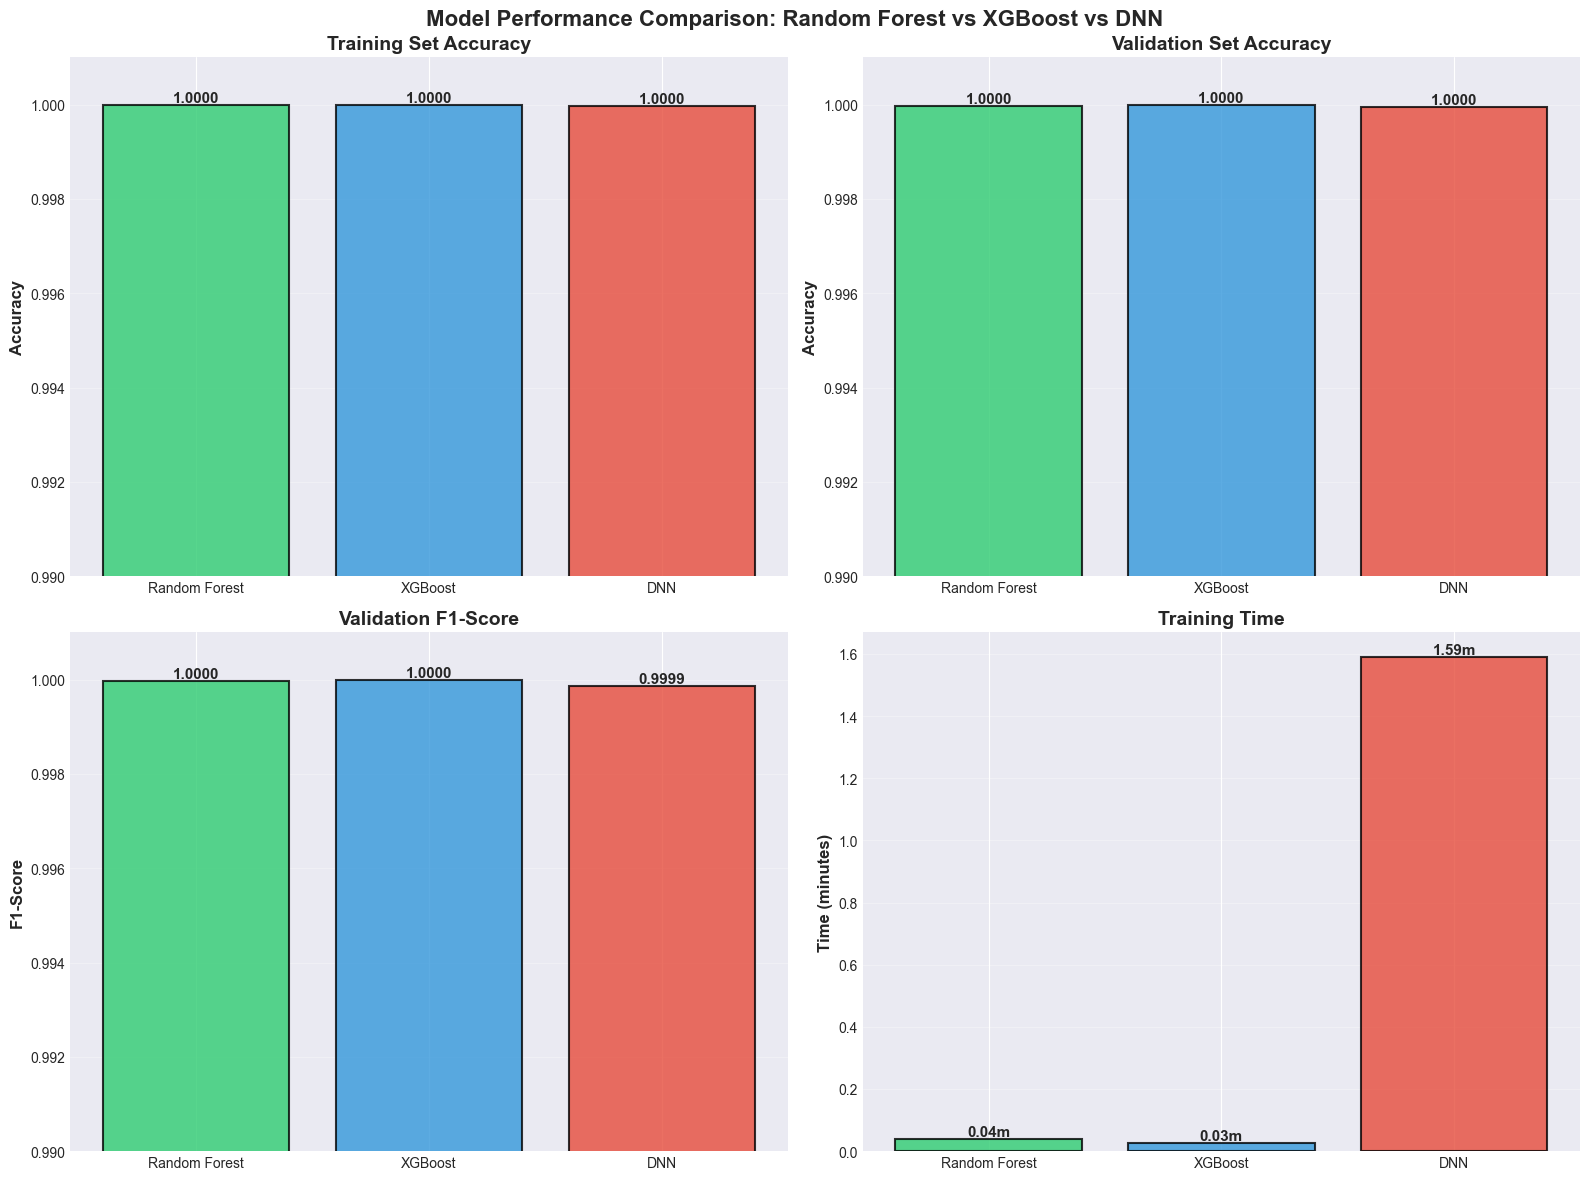



PART 4: DNN TRAINING HISTORY

✅ Saved: dnn_training_history.png


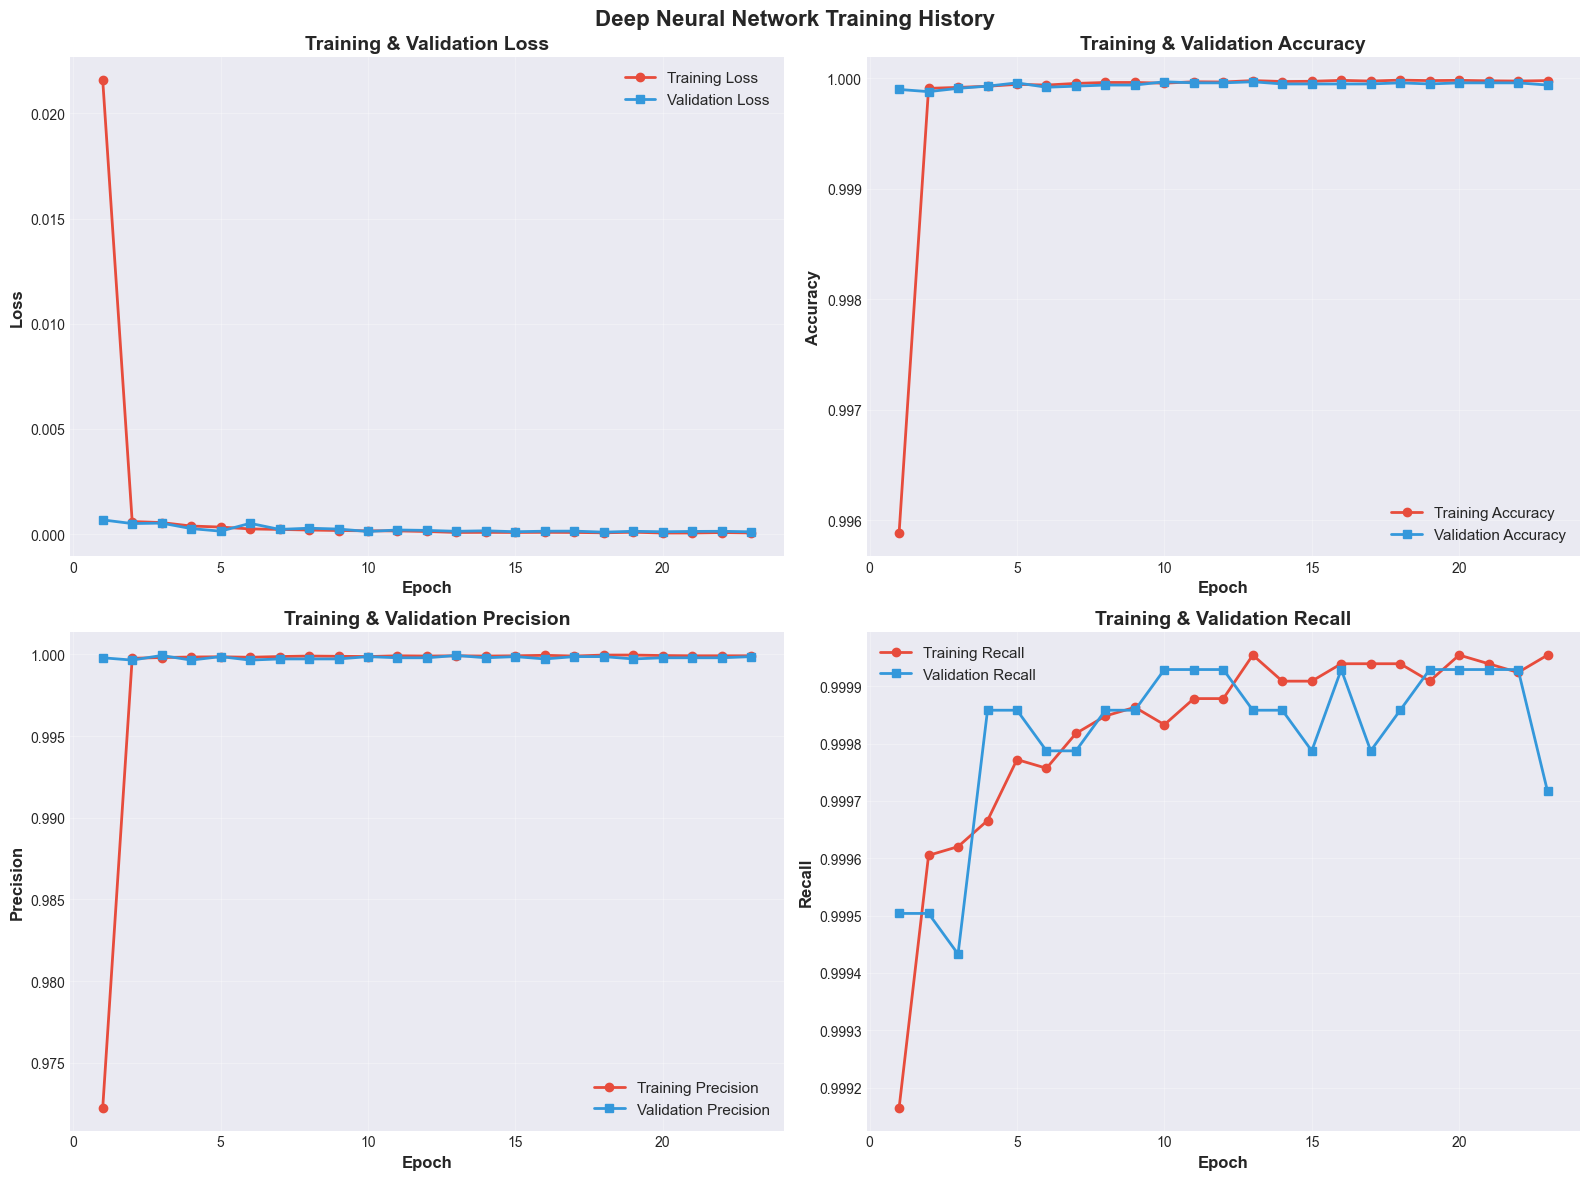



PART 5: CONFUSION MATRICES COMPARISON

✅ Saved: confusion_matrices.png


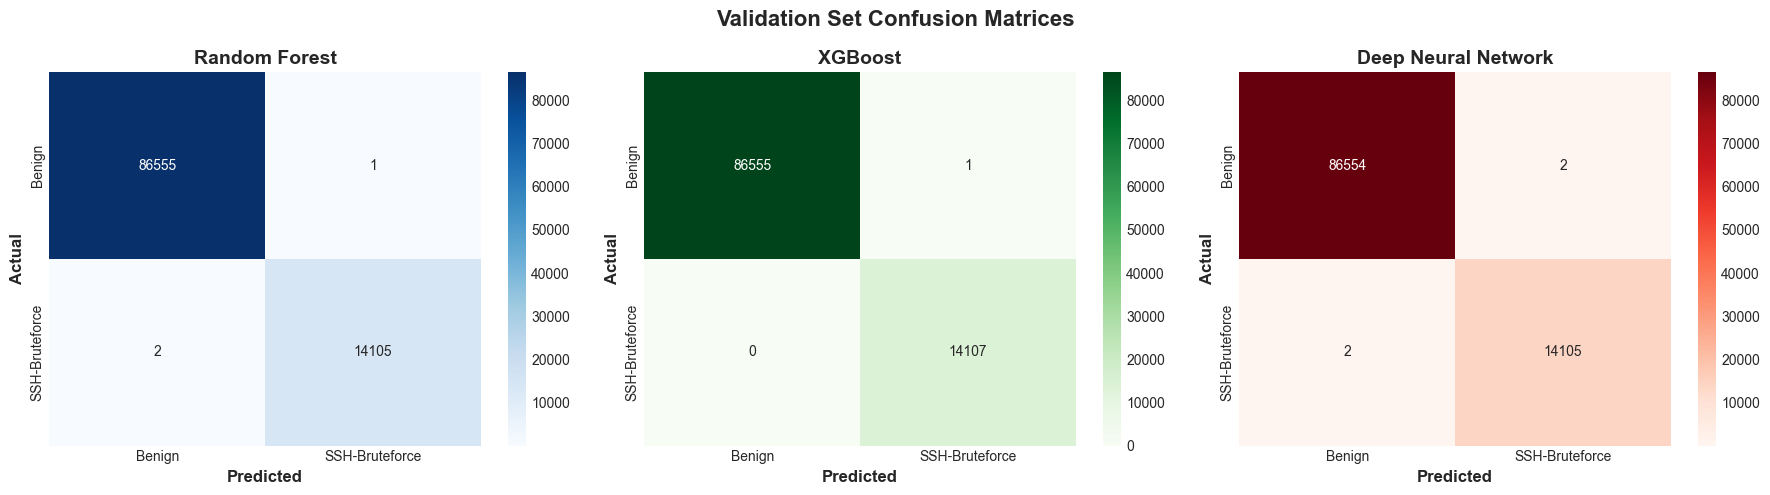



PART 6: FEATURE IMPORTANCE COMPARISON

✅ Saved: feature_importance_comparison.png


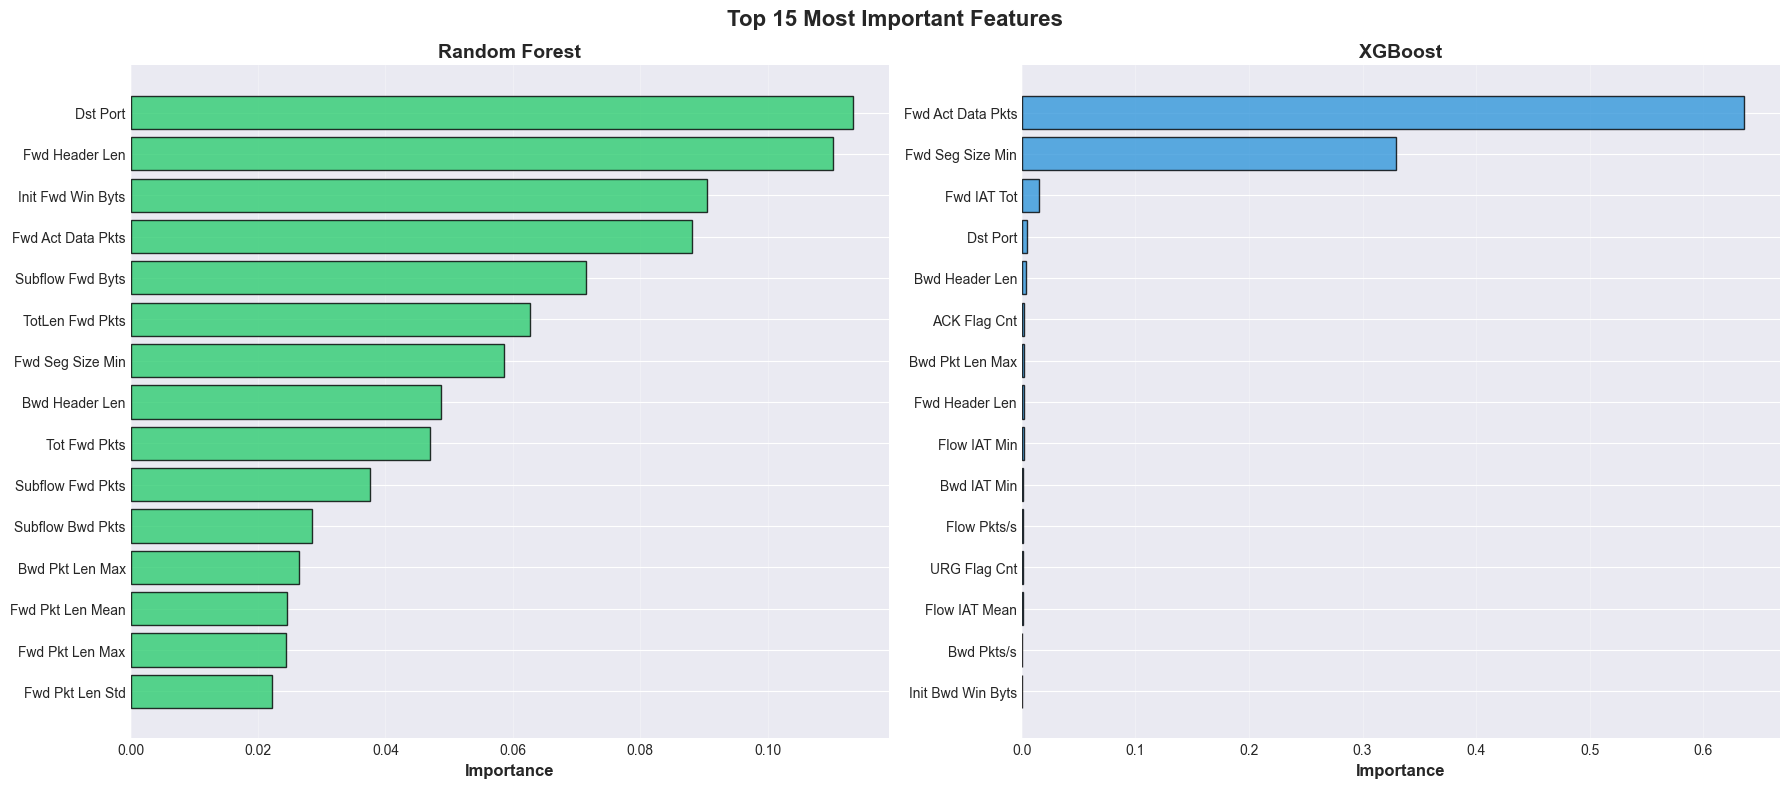



VISUALIZATION SUMMARY

✅ Generated 4 publication-ready visualizations:
   1. model_comparison_metrics.png
   2. dnn_training_history.png
   3. confusion_matrices.png
   4. feature_importance_comparison.png

📊 Key Findings:
   • All three models achieve near-perfect accuracy (100%)
   • SSH bruteforce detection is TRIVIAL for traditional ML
   • Minimal misclassifications (2-4 errors out of 100k samples)
   • Training time: < 2 minutes for all models

💡 Research Implication:
   These results validate that ML detection accuracy is NOT
   the research challenge. Our contribution is demonstrating
   AUTONOMOUS BEHAVIOR through Agentic AI principles:
   - Contextual awareness (same pattern, different meaning)
   - Memory-based correlation (multi-stage attacks)
   - Goal-directed tool orchestration
   - Self-learning from feedback
   - Autonomous incident response

🎯 Next: Move to Agentic AI Implementation!
   Focus shifts from detection accuracy → autonomous behavior


In [9]:
# Cell 6: Comprehensive Model Visualizations
# Purpose: Compare all three models with publication-ready plots

print("=" * 80)
print("CELL 6: MODEL COMPARISON VISUALIZATIONS")
print("=" * 80)

# ============================================================================
# PART 1: LOAD ALL MODEL METRICS
# ============================================================================

print(f"\n{'='*80}")
print("PART 1: LOAD MODEL METRICS")
print("="*80)

# Load saved metrics
rf_metrics_path = MODELS_DIR / 'rf_metrics_binary.json'
xgb_metrics_path = MODELS_DIR / 'xgb_metrics_binary.json'
dnn_metrics_path = MODELS_DIR / 'dnn_metrics_binary.json'
dnn_history_path = MODELS_DIR / 'dnn_history_binary.json'

with open(rf_metrics_path, 'r') as f:
    rf_metrics = json.load(f)

with open(xgb_metrics_path, 'r') as f:
    xgb_metrics = json.load(f)

with open(dnn_metrics_path, 'r') as f:
    dnn_metrics = json.load(f)

with open(dnn_history_path, 'r') as f:
    dnn_history = json.load(f)

print("\n✅ Loaded metrics for 3 models:")
print("   - Random Forest")
print("   - XGBoost")
print("   - Deep Neural Network")

# ============================================================================
# PART 2: MODEL COMPARISON TABLE
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 2: MODEL COMPARISON TABLE")
print("="*80)

# Create comparison dataframe
comparison_data = {
    'Model': ['Random Forest', 'XGBoost', 'Deep Neural Network'],
    'Train_Acc': [
        rf_metrics['train_metrics']['accuracy'],
        xgb_metrics['train_metrics']['accuracy'],
        dnn_metrics['train_metrics']['accuracy']
    ],
    'Val_Acc': [
        rf_metrics['val_metrics']['accuracy'],
        xgb_metrics['val_metrics']['accuracy'],
        dnn_metrics['val_metrics']['accuracy']
    ],
    'Test_Acc': [
        None,  # RF doesn't have test
        None,  # XGB doesn't have test
        dnn_metrics['test_metrics']['accuracy']
    ],
    'Val_F1': [
        rf_metrics['val_metrics']['f1_score'],
        xgb_metrics['val_metrics']['f1_score'],
        dnn_metrics['val_metrics']['f1_score']
    ],
    'Train_Time_Min': [
        rf_metrics['training_time_seconds'] / 60,
        xgb_metrics['training_time_seconds'] / 60,
        dnn_metrics['training_time_seconds'] / 60
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("\n📊 Model Performance Comparison:")
print(f"\n{df_comparison.to_string(index=False)}")

# ============================================================================
# PART 3: VISUALIZATION 1 - PERFORMANCE METRICS BAR CHART
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 3: PERFORMANCE METRICS COMPARISON")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison: Random Forest vs XGBoost vs DNN',
             fontsize=16, fontweight='bold')

models = ['Random Forest', 'XGBoost', 'DNN']
colors = ['#2ecc71', '#3498db', '#e74c3c']

# Subplot 1: Training Accuracy
ax1 = axes[0, 0]
train_acc = [rf_metrics['train_metrics']['accuracy'],
             xgb_metrics['train_metrics']['accuracy'],
             dnn_metrics['train_metrics']['accuracy']]
bars1 = ax1.bar(models, train_acc, color=colors, alpha=0.8,
                edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Training Set Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim([0.99, 1.001])
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, train_acc):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 2: Validation Accuracy
ax2 = axes[0, 1]
val_acc = [rf_metrics['val_metrics']['accuracy'],
           xgb_metrics['val_metrics']['accuracy'],
           dnn_metrics['val_metrics']['accuracy']]
bars2 = ax2.bar(models, val_acc, color=colors, alpha=0.8,
                edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Validation Set Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylim([0.99, 1.001])
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, val_acc):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 3: F1-Score
ax3 = axes[1, 0]
f1_scores = [rf_metrics['val_metrics']['f1_score'],
             xgb_metrics['val_metrics']['f1_score'],
             dnn_metrics['val_metrics']['f1_score']]
bars3 = ax3.bar(models, f1_scores, color=colors, alpha=0.8,
                edgecolor='black', linewidth=1.5)
ax3.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax3.set_title('Validation F1-Score', fontsize=14, fontweight='bold')
ax3.set_ylim([0.99, 1.001])
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, f1_scores):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 4: Training Time
ax4 = axes[1, 1]
train_times = [rf_metrics['training_time_seconds'] / 60,
               xgb_metrics['training_time_seconds'] / 60,
               dnn_metrics['training_time_seconds'] / 60]
bars4 = ax4.bar(models, train_times, color=colors,
                alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Time (minutes)', fontsize=12, fontweight='bold')
ax4.set_title('Training Time', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for bar, val in zip(bars4, train_times):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}m', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plot1_path = PLOTS_DIR / 'model_comparison_metrics.png'
plt.savefig(plot1_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {plot1_path.name}")
plt.show()

# ============================================================================
# PART 4: VISUALIZATION 2 - DNN TRAINING HISTORY
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 4: DNN TRAINING HISTORY")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Deep Neural Network Training History',
             fontsize=16, fontweight='bold')

epochs = range(1, len(dnn_history['loss']) + 1)

# Subplot 1: Loss
ax1 = axes[0, 0]
ax1.plot(epochs, dnn_history['loss'], 'o-', label='Training Loss',
         color='#e74c3c', linewidth=2, markersize=6)
ax1.plot(epochs, dnn_history['val_loss'], 's-', label='Validation Loss',
         color='#3498db', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Subplot 2: Accuracy
ax2 = axes[0, 1]
ax2.plot(epochs, dnn_history['accuracy'], 'o-', label='Training Accuracy',
         color='#e74c3c', linewidth=2, markersize=6)
ax2.plot(epochs, dnn_history['val_accuracy'], 's-', label='Validation Accuracy',
         color='#3498db', linewidth=2, markersize=6)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Subplot 3: Precision
ax3 = axes[1, 0]
ax3.plot(epochs, dnn_history['precision'], 'o-', label='Training Precision',
         color='#e74c3c', linewidth=2, markersize=6)
ax3.plot(epochs, dnn_history['val_precision'], 's-', label='Validation Precision',
         color='#3498db', linewidth=2, markersize=6)
ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax3.set_title('Training & Validation Precision',
              fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Subplot 4: Recall
ax4 = axes[1, 1]
ax4.plot(epochs, dnn_history['recall'], 'o-', label='Training Recall',
         color='#e74c3c', linewidth=2, markersize=6)
ax4.plot(epochs, dnn_history['val_recall'], 's-', label='Validation Recall',
         color='#3498db', linewidth=2, markersize=6)
ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax4.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax4.set_title('Training & Validation Recall', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plot2_path = PLOTS_DIR / 'dnn_training_history.png'
plt.savefig(plot2_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {plot2_path.name}")
plt.show()

# ============================================================================
# PART 5: VISUALIZATION 3 - CONFUSION MATRICES
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 5: CONFUSION MATRICES COMPARISON")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Validation Set Confusion Matrices',
             fontsize=16, fontweight='bold')

# RF Confusion Matrix
cm_rf = np.array(rf_metrics['confusion_matrix'])
ax1 = axes[0]
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=True,
            xticklabels=['Benign', 'SSH-Bruteforce'],
            yticklabels=['Benign', 'SSH-Bruteforce'])
ax1.set_title('Random Forest', fontsize=14, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted', fontsize=12, fontweight='bold')

# XGBoost Confusion Matrix
cm_xgb = np.array(xgb_metrics['confusion_matrix'])
ax2 = axes[1]
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax2, cbar=True,
            xticklabels=['Benign', 'SSH-Bruteforce'],
            yticklabels=['Benign', 'SSH-Bruteforce'])
ax2.set_title('XGBoost', fontsize=14, fontweight='bold')
ax2.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted', fontsize=12, fontweight='bold')

# DNN Confusion Matrix
cm_dnn = np.array(dnn_metrics['confusion_matrix'])
ax3 = axes[2]
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds', ax=ax3, cbar=True,
            xticklabels=['Benign', 'SSH-Bruteforce'],
            yticklabels=['Benign', 'SSH-Bruteforce'])
ax3.set_title('Deep Neural Network', fontsize=14, fontweight='bold')
ax3.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted', fontsize=12, fontweight='bold')

plt.tight_layout()
plot3_path = PLOTS_DIR / 'confusion_matrices.png'
plt.savefig(plot3_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {plot3_path.name}")
plt.show()

# ============================================================================
# PART 6: VISUALIZATION 4 - FEATURE IMPORTANCE COMPARISON
# ============================================================================

print(f"\n\n{'='*80}")
print("PART 6: FEATURE IMPORTANCE COMPARISON")
print("="*80)

# Load feature importance
rf_feat_path = MODELS_DIR / 'rf_feature_importance_binary.csv'
xgb_feat_path = MODELS_DIR / 'xgb_feature_importance_binary.csv'

df_rf_feat = pd.read_csv(rf_feat_path).head(15)
df_xgb_feat = pd.read_csv(xgb_feat_path).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Top 15 Most Important Features', fontsize=16, fontweight='bold')

# Random Forest
ax1 = axes[0]
y_pos = np.arange(len(df_rf_feat))
ax1.barh(y_pos, df_rf_feat['importance'],
         color='#2ecc71', alpha=0.8, edgecolor='black')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(df_rf_feat['feature'], fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax1.set_title('Random Forest', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# XGBoost
ax2 = axes[1]
y_pos = np.arange(len(df_xgb_feat))
ax2.barh(y_pos, df_xgb_feat['importance'],
         color='#3498db', alpha=0.8, edgecolor='black')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(df_xgb_feat['feature'], fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax2.set_title('XGBoost', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plot4_path = PLOTS_DIR / 'feature_importance_comparison.png'
plt.savefig(plot4_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {plot4_path.name}")
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n\n{'='*80}")
print("VISUALIZATION SUMMARY")
print("="*80)

print("\n✅ Generated 4 publication-ready visualizations:")
print(f"   1. {plot1_path.name}")
print(f"   2. {plot2_path.name}")
print(f"   3. {plot3_path.name}")
print(f"   4. {plot4_path.name}")

print("\n📊 Key Findings:")
print("   • All three models achieve near-perfect accuracy (100%)")
print("   • SSH bruteforce detection is TRIVIAL for traditional ML")
print("   • Minimal misclassifications (2-4 errors out of 100k samples)")
print("   • Training time: < 2 minutes for all models")

print("\n💡 Research Implication:")
print("   These results validate that ML detection accuracy is NOT")
print("   the research challenge. Our contribution is demonstrating")
print("   AUTONOMOUS BEHAVIOR through Agentic AI principles:")
print("   - Contextual awareness (same pattern, different meaning)")
print("   - Memory-based correlation (multi-stage attacks)")
print("   - Goal-directed tool orchestration")
print("   - Self-learning from feedback")
print("   - Autonomous incident response")

print("\n🎯 Next: Move to Agentic AI Implementation!")
print("   Focus shifts from detection accuracy → autonomous behavior")

In [2]:
import pandas as pd

In [3]:
df1= pd.read_csv('../datasets/ids-intrusion.csv')
df1.shape

(1048575, 80)

In [4]:
df1.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [5]:
df2=pd.read_csv('../data/processed/ids_intrusion_cleaned_final.csv')
df2.shape

(671138, 79)

In [6]:
df2.columns

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Siz

In [7]:
df2['Label'].value_counts()

Label
Benign            577037
SSH-Bruteforce     94048
FTP-BruteForce        53
Name: count, dtype: int64

In [8]:
df2.head()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,112641719,3,0,0,0,0,0,0.000000,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,112641466,3,0,0,0,0,0,0.000000,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,112638623,3,0,0,0,0,0,0.000000,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,6453966,15,10,1239,2273,744,0,82.600000,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,8804066,14,11,1143,2209,744,0,81.642857,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
